# An example for Fisher analysis

Based on Arcade measurement of excess radio background

In [1]:
import numpy as np
from pymultinest.solve import solve
import PyLab as PL
import time, getdist, os, corner
from getdist import plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'text.usetex': True,
    'font.family':'Times',
    'text.latex.preamble': r'\usepackage{newtxtext,newtxmath}'})
%matplotlib inline
%load_ext autoreload
%autoreload 2
%matplotlib widget

[cangtaodeMacBook-Pro.local:47650] shmem: mmap: an error occurred while determining whether or not /var/folders/4l/x26d55ys0r77d01llftzzrfh0000gn/T//ompi.cangtaodeMacBook-Pro.501/jf.0/3078488064/sm_segment.cangtaodeMacBook-Pro.501.b77e0000.0 could be created.


# First define models and data

Model for temperature

\begin{equation}
T = T_{\rm{CMB}} + T_{\rm{R}} \left(\frac{\nu}{{\rm{GHz}}}\right)^\beta
\end{equation}

In [2]:
params_fid = [2.730, 1.203, -2.613]
Arcade_Data = {
        'Frequency_GHz': np.array([0.022, 0.045, 0.408, 1.42, 3.2, 3.41, 7.97, 8.33, 9.72, 10.49, 29.5, 31, 90]),
        # 'Temperature_K': np.array([21200, 4355, 16.24, 3.213, 2.792, 2.771, 2.765, 2.741, 2.732, 2.732, 2.529, 2.573, 2.706]),
        'Uncertainty_K': np.array([5125, 520, 3.4, 0.53, 0.01, 0.009, 0.014, 0.016, 0.006, 0.006, 0.155, 0.076, 0.019])}
    
def model(Tcmb, TR, Beta):
    v = Arcade_Data['Frequency_GHz']
    v0 = 1.0
    T = Tcmb + TR*(v/v0)**Beta
    return T

# Get Fiducial data
Arcade_Data['Temperature_K'] = model(Tcmb=params_fid[0], TR = params_fid[1], Beta = params_fid[2])


# Compute derivative

In [3]:
def compute_derivative(param_idx, width = 0.01):
    # Not suitable for fid = 0
    p1 = params_fid.copy()
    p2 = params_fid.copy()
    p1[param_idx] = params_fid[param_idx] - width/2
    p2[param_idx] = params_fid[param_idx] + width/2
    p = p1
    T1 = model(Tcmb=p[0], TR=p[1], Beta=p[2])
    p = p2
    
    T2 = model(Tcmb=p[0], TR=p[1], Beta=p[2])
    dx = width/2.0
    T0 = Arcade_Data['Temperature_K']
    dTdp_1 = (T0 - T1) / dx
    dTdp_2 = (T2 - T0) / dx
    r = (dTdp_1 + dTdp_2)/2
    return r

ndim = 3
dTdp = []
for pid in np.arange(0, ndim):
    dTdp_ = compute_derivative(param_idx=pid, width=0.01)
    dTdp.append(dTdp_)


# Build Fisher Matrix

In [4]:
Fish = np.zeros([ndim, ndim])

sigma = Arcade_Data['Uncertainty_K']
for id1 in np.arange(0, ndim):
    for id2 in np.arange(0, ndim):
        d1 = dTdp[id1]
        d2 = dTdp[id2]
        F12 = np.sum(d1 * d2/sigma**2.0)
        Fish[id1, id2] = F12
Fish_inv = np.linalg.inv(Fish)


As a quick test, print out the errors

In [5]:
names = ['Tcmb', 'TR', 'Beta']
for idx in [0, 1, 2]:
    name = names[idx]
    s = Fish_inv[idx, idx]**0.5
    MSG = name + " = {:.3f} +- {:.3f}".format(params_fid[idx], s)
    print(MSG)

Tcmb = 2.730 +- 0.004
TR = 1.203 +- 0.134
Beta = -2.613 +- 0.042


# Plot samples with GetDist

Removed no burn in


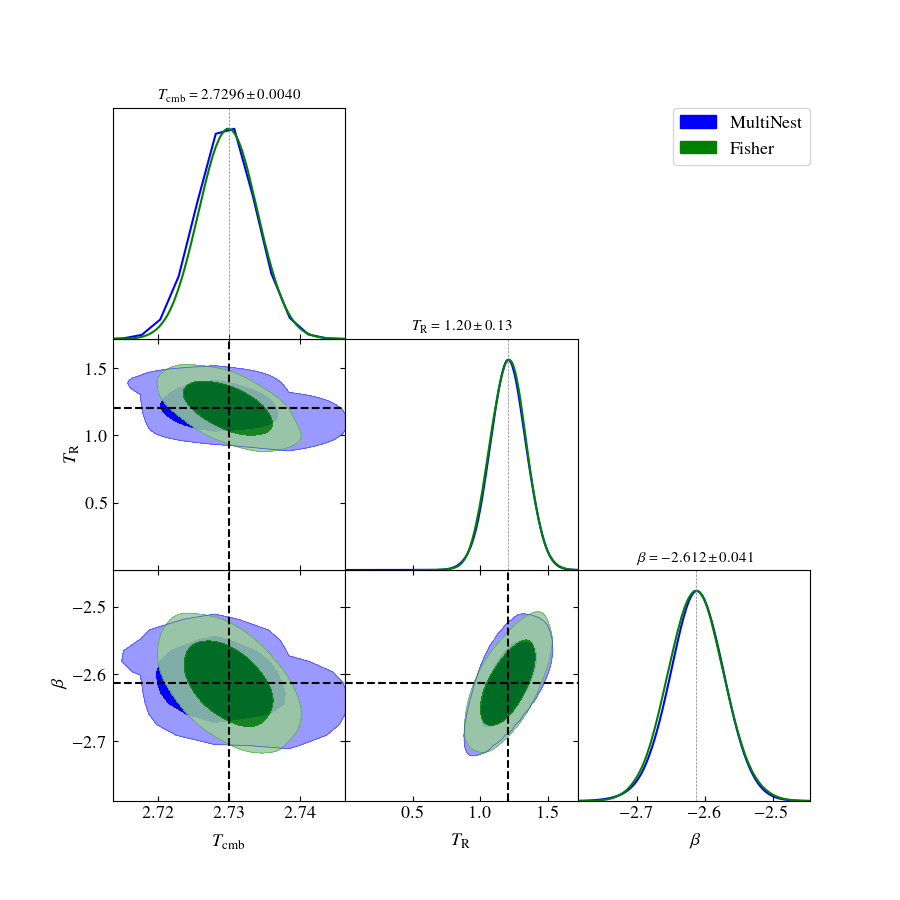

In [6]:
def make_getdist_samples(n = 10000):
    fish_samples = np.random.multivariate_normal(params_fid, Fish_inv, size = n)
    names_latex = ['T_{\mathrm{cmb}}', 'T_{\mathrm{R}}', '\\beta']
    samples = getdist.mcsamples.MCSamples(samples=fish_samples, names=names, labels=names_latex)
    return samples, fish_samples

sample_1 = getdist.mcsamples.loadMCSamples('/Users/cangtao/FileVault/Soft/PyLab/examples/MultiNest/data/arcade_')
sample_2, _ = make_getdist_samples()
p = sample_1.getParams()
g = plots.getSubplotPlotter(subplot_size = 3)
g.settings.axes_fontsize=14
g.settings.title_limit_fontsize = 12
g.settings.lab_fontsize =14
g.settings.axes_labelsize = 14 # Size of axis label
g.settings.legend_fontsize = 14 # Legend size

g.triangle_plot(
    [sample_1, sample_2],
    width_inch=12,
    contour_colors = ['b', 'g'],
    legend_labels= ['MultiNest', 'Fisher'],
    filled = True,
    line_args=[
        {'lw':1.5,'ls':'-', 'color':'b'},
        {'lw':1.5,'ls':'-', 'color':'g'},
        ],
    title_limit = 1,
    # param_limits = {'fR': [4.5, 5.5], 'LX' : [39, 42], 'zcut' : [14, 20]}, # set axis limits
    markers = {
        'Tcmb' : params_fid[0],
        'TR' : params_fid[1],
        'Beta' : params_fid[2]}, # Mark value, use best-fit for this example
    marker_args = {'lw' : 1.5, 'color': 'k'}, # Marker setting, lw - LineWidth, can also set color etc
    )


# Still not convinced? Plot with corner

Removed no burn in


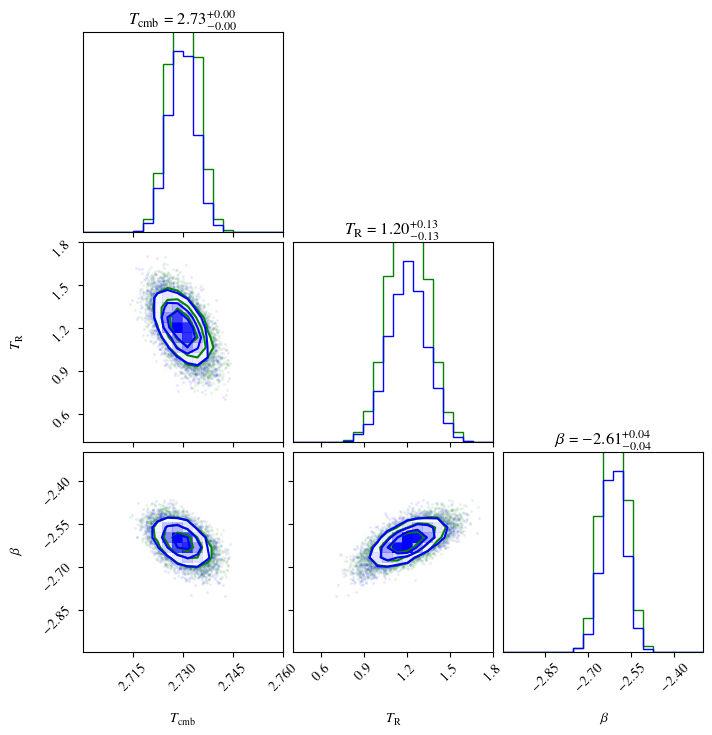

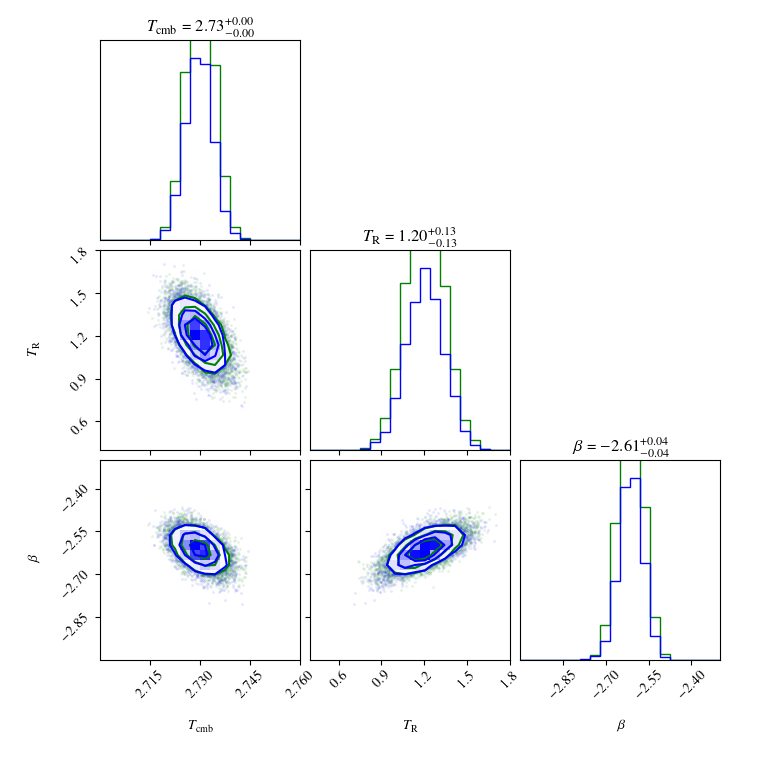

In [7]:
sample_multinest = np.loadtxt('/Users/cangtao/FileVault/Soft/PyLab/examples/MultiNest/data/arcade_post_equal_weights.dat')[:, 0:ndim]
_, sample_fish = make_getdist_samples()
labels = ['T_{\mathrm{cmb}}', 'T_{\mathrm{R}}', '\\beta']
labels = ['Tc', 'TR', 'Beta']
labels = ['$T_{\mathrm{cmb}}$', '$T_{\mathrm{R}}$', '$\\beta$']

plot_ranges = [
    [2.7, 2.76],
    [0.4, 1.8],
    [-3, -2.3]]
fig = corner.corner(sample_fish, labels=labels, color = 'g', show_titles=True, range = plot_ranges)
corner.corner(sample_multinest, labels=labels, color = 'b', show_titles=False, fig = fig, range = plot_ranges)

# plt.tight_layout()
# plt.savefig('/Users/cangtao/Desktop/tmp.pdf', bbox_inches = 'tight')
